# 📌 Customer Segmentation Using Unsupervised Learning

## Problem Statement
Customer segmentation is a key strategy used by businesses to understand customer behavior and target different groups effectively. By analyzing customer data, companies can group customers based on similar characteristics such as income and spending patterns.

## Objective
The objective of this project is to segment customers from the Mall Customers dataset using unsupervised learning techniques.

### In this project, we will:
- Perform Exploratory Data Analysis (EDA) to understand the dataset
- Apply K-Means Clustering to identify customer segments
- Use Principal Component Analysis (PCA) for visualization
- Provide marketing strategies for each customer segment

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [2]:
df = pd.read_csv("Mall_Customers.csv")

df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
df.columns

Index(['CustomerID', 'Genre', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='str')

In [4]:
df.rename(columns={"Genre": "Gender"}, inplace=True)

df.columns

Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='str')

## 📊 Dataset Description

The dataset contains information about customers visiting a mall. It includes the following features:

- **CustomerID**: Unique identifier for each customer  
- **Gender**: Gender of the customer (Male/Female)  
- **Age**: Age of the customer  
- **Annual Income (k$)**: Annual income of the customer in thousands  
- **Spending Score (1–100)**: Score assigned based on customer spending behavior  

## 🧹 Data Cleaning and Preprocessing
In this step, we check for missing values, remove unnecessary columns, and convert categorical data into numerical format for clustering.

In [5]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [6]:
df = df.drop("CustomerID", axis=1)

In [7]:
df["Gender"] = df["Gender"].map({"Male": 1, "Female": 0})

df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,19,15,39
1,1,21,15,81
2,0,20,16,6
3,0,23,16,77
4,0,31,17,40


## 🔍 Exploratory Data Analysis (EDA)

In this section, we analyze the dataset using statistical summaries and visualizations to understand customer behavior.

In [8]:
df.describe()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,0.440000,38.850000,60.560000,50.200000
std,0.497633,13.969007,26.264721,25.823522
min,0.000000,18.000000,15.000000,1.000000
25%,0.000000,28.750000,41.500000,34.750000
50%,0.000000,36.000000,61.500000,50.000000
75%,1.000000,49.000000,78.000000,73.000000
max,1.000000,70.000000,137.000000,99.000000


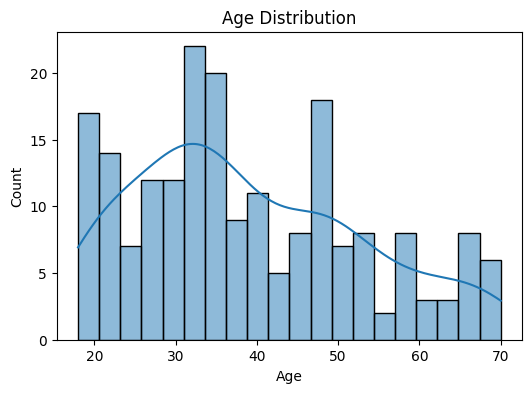

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.histplot(df["Age"], bins=20, kde=True)
plt.title("Age Distribution")
plt.show()

### Insight
Most customers fall in the age group of 20 to 40 years, indicating that the mall mainly targets young and middle-aged individuals.

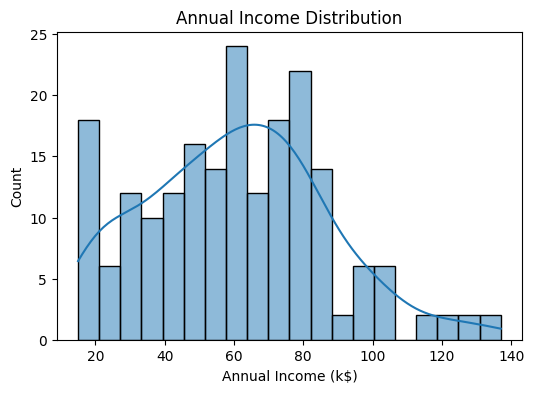

In [10]:
plt.figure(figsize=(6,4))
sns.histplot(df["Annual Income (k$)"], bins=20, kde=True)
plt.title("Annual Income Distribution")
plt.show()

### Insight
The annual income is widely distributed, showing that customers belong to different income levels.

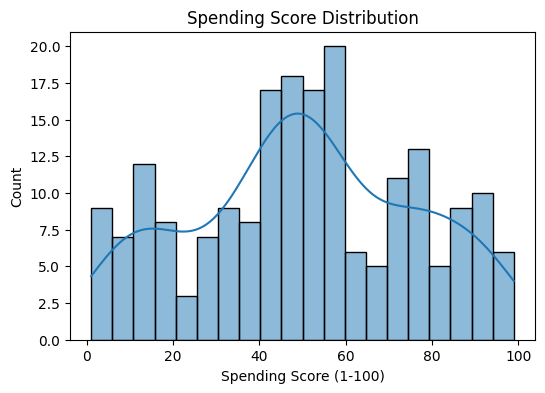

In [11]:
plt.figure(figsize=(6,4))
sns.histplot(df["Spending Score (1-100)"], bins=20, kde=True)
plt.title("Spending Score Distribution")
plt.show()

### Insight
The spending score varies significantly, indicating the presence of both low and high spending customers.

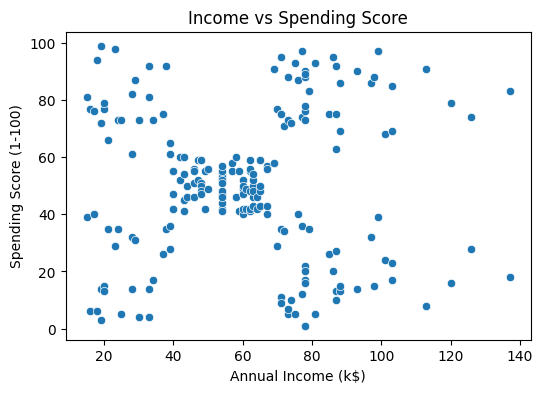

In [13]:
plt.figure(figsize=(6,4))
sns.scatterplot(
    x=df["Annual Income (k$)"],
    y=df["Spending Score (1-100)"]
)

plt.title("Income vs Spending Score")
plt.show()

### Insight
The plot shows clear patterns between income and spending, suggesting that customers can be grouped into distinct segments using clustering.

## ⚙️ Feature Scaling

Before applying K-Means clustering, we scale the features to ensure all variables contribute equally to the model.

In [15]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_data = scaler.fit_transform(df)

## 📉 Elbow Method

The Elbow Method is used to determine the optimal number of clusters by plotting the Within-Cluster Sum of Squares (WCSS).

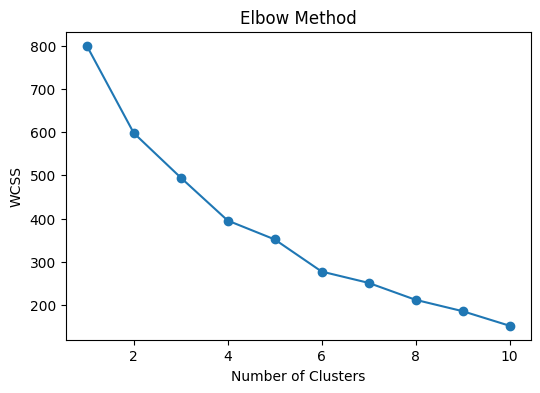

In [16]:
from sklearn.cluster import KMeans

wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(6,4))
plt.plot(range(1, 11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

### Insight
The elbow point appears around 5 clusters, indicating that 5 is the optimal number of clusters for this dataset.

## 🤖 K-Means Clustering

K-Means clustering is applied to segment customers into distinct groups based on their features.

In [17]:
kmeans = KMeans(n_clusters=5, random_state=42)

clusters = kmeans.fit_predict(scaled_data)

df["Cluster"] = clusters

df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,19,15,39,2
1,1,21,15,81,2
2,0,20,16,6,4
3,0,23,16,77,4
4,0,31,17,40,4


## 📉 PCA for Cluster Visualization

Principal Component Analysis (PCA) is used to reduce the dataset to two dimensions for visualization of clusters.

In [18]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

pca_components = pca.fit_transform(scaled_data)

pca_df = pd.DataFrame(data=pca_components, columns=["PC1", "PC2"])

pca_df["Cluster"] = clusters

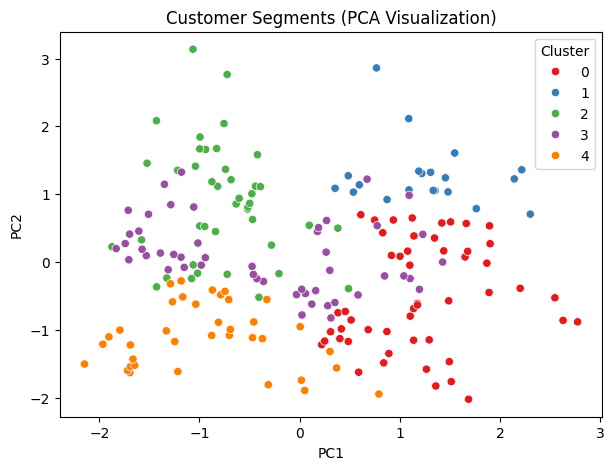

In [19]:
plt.figure(figsize=(7,5))

sns.scatterplot(
    x="PC1",
    y="PC2",
    hue="Cluster",
    data=pca_df,
    palette="Set1"
)

plt.title("Customer Segments (PCA Visualization)")
plt.show()

## 📊 Cluster Analysis

We analyze the characteristics of each cluster by calculating the average values of features within each group.

In [21]:
df.groupby("Cluster").mean()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,,
0,0.509804,56.470588,46.098039,39.313725
1,1.000000,39.500000,85.150000,14.050000
2,1.000000,28.690476,60.904762,70.238095
3,0.000000,37.897959,82.122449,54.448980
4,0.000000,27.315789,38.842105,56.210526


## 🎯 Marketing Strategies for Each Segment

Based on the clustering results, the following strategies can be applied:

### Cluster 0 — High Income, High Spending
- Offer premium memberships
- Provide exclusive discounts and early access to products
- Focus on loyalty programs

### Cluster 1 — Low Income, Low Spending
- Provide discounts and budget-friendly deals
- Promote seasonal sales and offers

### Cluster 2 — Young High Spenders
- Use social media marketing and influencers
- Promote trendy and popular products

### Cluster 3 — Moderate Income Customers
- Provide personalized recommendations
- Offer reward points and incentives

### Cluster 4 — High Income but Low Spending
- Target with premium product advertisements
- Encourage spending through personalized promotions

## 📝 Conclusion

In this project, we applied K-Means clustering to segment customers based on their demographic and spending behavior. Using PCA, we visualized the clusters effectively.

The analysis revealed distinct customer groups with different spending patterns. These insights can help businesses design targeted marketing strategies, improve customer engagement, and increase revenue.